In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from geostat_isoscapes_tools import sisal_utils, utils
import seaborn as sns 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
sns.set_style('darkgrid')

Temperature data is from [Mario Krapp's database](https://osf.io/8n43x/) and is associated to [this paper](https://www.nature.com/articles/s41597-021-01009-3#Abs1)

### **Detailed procedure for temperature retrieval and conversion**

##### TEMPERATURE DATASET

In [2]:
fn = '../data/temperature/temp_800ka_ann.nc'

with xr.open_dataset(filename_or_obj=fn, engine='netcdf4',decode_times=False) as file:
    print(file)
    temp_xda = file.temp

LON = temp_xda.coords['lon'].values.copy()
LAT = temp_xda.coords['lat'].values.copy()
TIME = temp_xda['time'].values.copy()

<xarray.Dataset> Size: 829MB
Dimensions:  (time: 800, lat: 360, lon: 720)
Coordinates:
  * time     (time) float64 6kB -7.99e+05 -7.98e+05 -7.97e+05 ... -1e+03 0.0
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
Data variables:
    temp     (time, lat, lon) float32 829MB ...
Attributes:
    CDI:           Climate Data Interface version 1.9.9 (https://mpimet.mpg.d...
    Conventions:   CF-1.6
    description:   Linear Regression Model reconstruction
    command_line:  src/data/reconstruct.py -l data/processed/hadcm3_000-120_a...
    history:       Mon Mar 01 09:40:14 2021: cdo -f nc4 -z zip_9 -L -s -add -...
    CDO:           Climate Data Operators version 1.9.9 (https://mpimet.mpg.d...


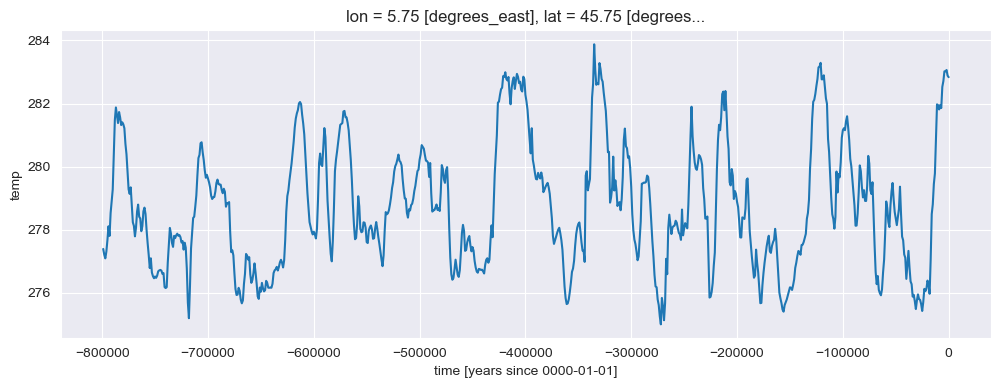

In [3]:
testloc_temp = temp_xda.sel(lon=5.66,lat=45.96,method='nearest')
plt.figure(figsize=(12,4))
testloc_temp.plot()
plt.show()
# note that the time unit is incorrect : according to paper, it is in yrs BP and not from 0000-01-01 (if that even makes sense)

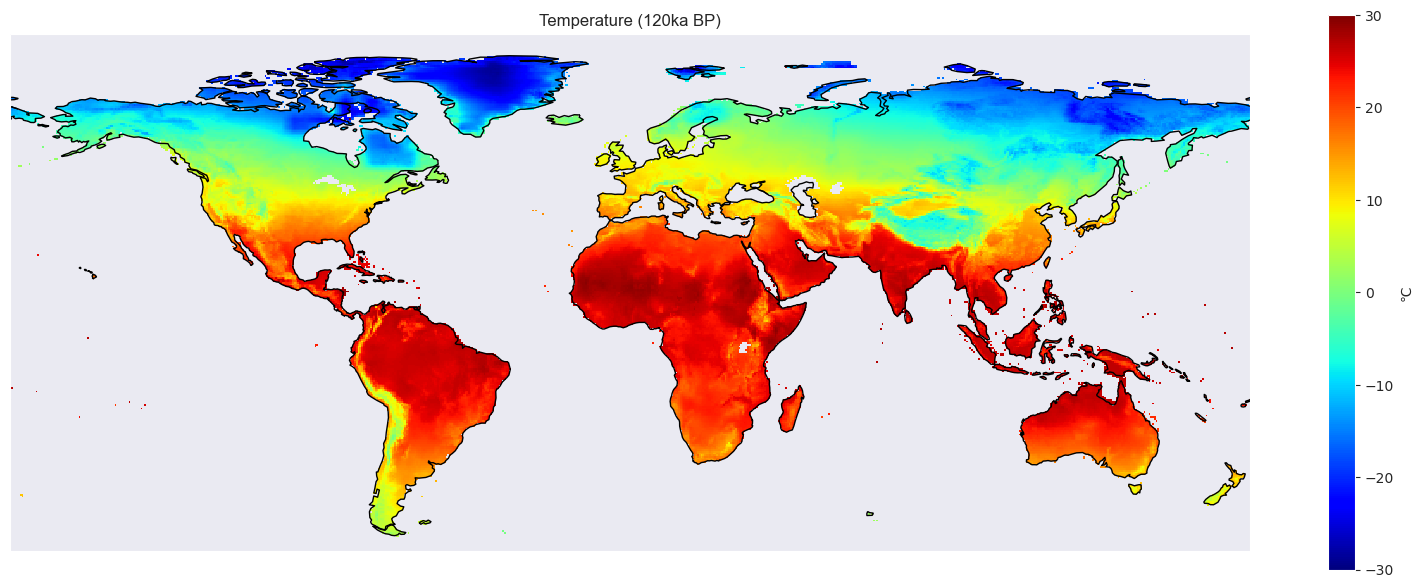

In [4]:
yearsBP = 120000
data_crs = ccrs.PlateCarree()
proj = ccrs.PlateCarree()
temp_to_plot = temp_xda.sel(time=-yearsBP).values.copy()

fig, ax = plt.subplots(1,1,figsize=(20,8),subplot_kw={'projection':proj})
ax.add_feature(cfeature.COASTLINE,zorder=2)
ax.set_extent((-179.9,179.9,-60,90),crs=data_crs)

temp_to_plot -= 273.15
Norm = Normalize
vmin = -30.
vmax = 30.
units = u'\u2103'
variable = "Temperature"
cmap = mpl.colormaps['jet']
plt.rcParams['font.family'] = 'DejaVu Sans'
im = ax.pcolormesh(LON,LAT,temp_to_plot,norm=Norm(vmin,vmax),cmap=cmap,rasterized=True,transform=data_crs)
cbar = plt.colorbar(im,ax=ax,shrink=0.9,label=units)
ax.set_title(f"{variable} ({yearsBP//1000}ka BP)")
plt.show()

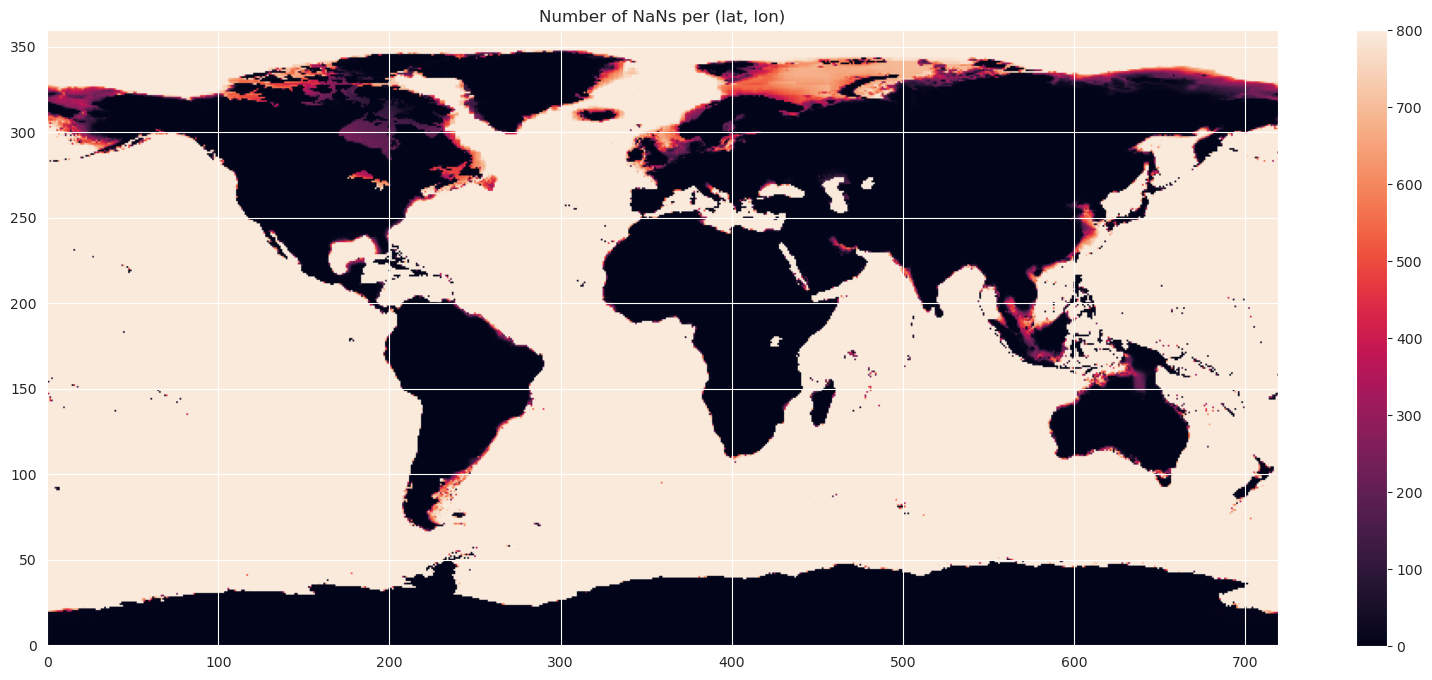

In [5]:
plt.figure(figsize=(20,8))
plt.imshow(temp_xda.isnull().sum(dim='time'), origin='lower')
plt.title('Number of NaNs per (lat, lon)')
plt.colorbar()
plt.show()

##### ATTRIBUTION OF TEMPERATURE TO SPELEOTHEMS SAMPLES

Conversion of the speleothems measurements from V-PDB standard units to drip-water equivalents in V-SMOW units, as in [Comas-Bru 2019](https://cp.copernicus.org/articles/15/1557/2019/)

We need a datframe with, at least, columns "sample_idx", "mineralogy", "age", "d18O","T".
1.  We will extract the 3 first columns + lon/lat coordinates in 2 extra columns
2.  We use the last 3 columns (location and age) to get T in the T dataset.


In [6]:
# Load SISAL data and get the valid samples indices (apply basic cleaning to remove superseded entities, exclude mixed mineralogy, samples without chronology...)
chrono = 'lin_interp_age'
data_df = sisal_utils.get_basic_cleaned_merged_sisal_data(chrono=chrono)
print(len(data_df),'usable samples')

-> loading database
   cleaning samples
loading and cleaning done.
242014 usable samples


In [7]:
# from scipy.interpolate import RegularGridInterpolator
# # super fast but some pb at some locations and times when there are nans in temp_xda 
# temp_values = temp_xda.values

# sample_times = - data_df[chrono].values
# sample_lats = data_df['latitude'].values
# sample_lons = data_df['longitude'].values

# points = np.column_stack([sample_times, sample_lats, sample_lons])
# # valid_points = points[mask]

# # Interpolator (time, lat, lon)
# interp_func = RegularGridInterpolator(
#     (TIME, LAT, LON),
#     temp_values,
#     bounds_error=False,
#     fill_value=np.nan,
# )

# data_to_convert = data_df.copy()
# data_to_convert['T_interp'] = pd.NA
# data_to_convert['T_interp'] = interp_func(points)

data_to_convert = sisal_utils.retrieve_T_RegularGridInterp(data_df=data_df,temp_xda=temp_xda,chrono=chrono,method='linear')


In [8]:
# Mask locs and times for which this method failed
mask_nan = data_to_convert['T_linear'].isna()
print('Interpolation failed for',mask_nan.sum(),'samples.')
# Apply the NN method for these points 
data_to_convert['T_nearest'] = pd.NA
data_to_convert.loc[mask_nan,'T_nearest'] = sisal_utils.retrieve_T_RegularGridInterp(data_df=data_df[mask_nan].copy(),temp_xda=temp_xda,chrono=chrono,method='nearest')['T_nearest']
# Gather T in a T column
data_to_convert.loc[ mask_nan,'T'] = data_to_convert.loc[mask_nan,'T_nearest']
data_to_convert.loc[~mask_nan,'T'] = data_to_convert.loc[~mask_nan,'T_linear']
mask_nans_final = data_to_convert['T'].isna()
print('After nearest_neighbour+interp, still no temperature for', mask_nans_final.sum(),'samples.')


Interpolation failed for 37968 samples.
After nearest_neighbour+interp, still no temperature for 10033 samples.


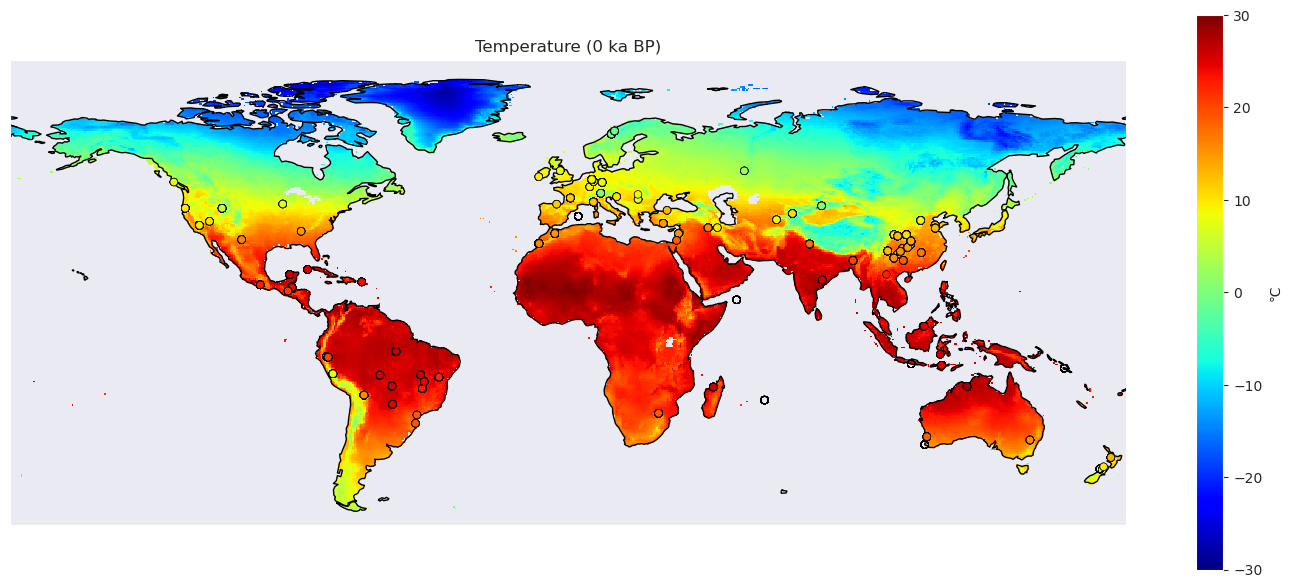

In [9]:
yearsBP  = 0 # positive values only
sisal_width = 500 # bin width in yr
data_crs = ccrs.PlateCarree()
proj     = ccrs.PlateCarree()

sisal_pts_Tinterp = data_to_convert.loc[(data_to_convert['lin_interp_age']>=yearsBP)
                                & (data_to_convert['lin_interp_age']<(yearsBP+sisal_width))
                                & (~mask_nan),
                                # &(data_to_convert['site_name']=='Jeita cave'),
                                ['longitude','latitude','lin_interp_age','T_linear','site_name']
                                ]

sisal_pts_T = data_to_convert.loc[(data_to_convert['lin_interp_age']>=yearsBP)
                                & (data_to_convert['lin_interp_age']<(yearsBP+sisal_width))
                                & (mask_nan),
                                # &(data_to_convert['site_name']=='Jeita cave'),
                                ['longitude','latitude','lin_interp_age','T_nearest','site_name']
                                ]

temp_to_plot = temp_xda.sel(time=-yearsBP).values.copy()

fig, ax = plt.subplots(1, 1, figsize=(18, 8), subplot_kw={'projection': proj})
ax.add_feature(cfeature.COASTLINE, zorder=2)
ax.set_extent((-179.9, 179.9, -60, 90), crs=data_crs)

temp_to_plot -= 273.15 
vmin, vmax = -30., 30.
units = u'\u2103'
variable = "Temperature"
cmap = mpl.colormaps['jet']
plt.rcParams['font.family'] = 'DejaVu Sans'

# Plot the xarray field
im = ax.pcolormesh(LON, LAT, temp_to_plot, norm=Normalize(vmin, vmax),
                   cmap=cmap, rasterized=True, transform=data_crs)

# Plot the SISAL point data as scatter
sc = ax.scatter(
    sisal_pts_Tinterp['longitude'],
    sisal_pts_Tinterp['latitude'],
    c = sisal_pts_Tinterp['T_linear']-273.15,
    s = 30,              # marker size
    edgecolor = 'k',
    linewidth = 0.5,
    cmap = cmap,
    norm = Normalize(vmin, vmax),
    transform = data_crs,
    zorder = 3
)

# Plot the SISAL point data as scatter
sc = ax.scatter(
    sisal_pts_T['longitude'],
    sisal_pts_T['latitude'],
    c = sisal_pts_T['T_nearest']-273.15,
    s = 30,              # marker size
    edgecolor = 'k',
    linewidth = 0.5,
    cmap = cmap,
    norm = Normalize(vmin, vmax),
    transform = data_crs,
    zorder = 3
)

cbar = plt.colorbar(im, ax=ax, shrink=0.9, label=units)
ax.set_title(f"{variable} ({yearsBP//1000} ka BP)")
plt.show()

##### CONVERSION OF PDB CALCITE VALUES TO VSMOW PRECIP VALUES

In [10]:
converted_data = sisal_utils.convert_calcite_to_drip_water(data_to_convert)

In [13]:
success = (~converted_data['d18Op_VSMOW_exactconv'].isna()).sum()
n = len(converted_data)
print(f'We successfully converted {success} samples out of {n} (roughly {round(success/n*100)}%).')

We successfully converted 231981 samples out of 242014 (roughly 96%).


### **Clean function for the conversion (to use in any script)**

In [14]:
# setup
chrono = 'lin_interp_age' # age to use
method = 'linear' # interp method
data_df = sisal_utils.get_basic_cleaned_merged_sisal_data(chrono=chrono) # speleo data
fn='../data/temperature/temp_800ka_ann.nc'
temp_xda = utils.load_xarray_datarray(fn).temp
# conversion
converted_data = sisal_utils.retrieve_temperature_and_convert_speleothem_d18O(data_df=data_df,
                                                                    chrono=chrono,
                                                                    temp_xda=temp_xda,
                                                                    method=method)

-> loading database
   cleaning samples
loading and cleaning done.
-> converting speleothem data
   linear interpolation failed for 37968 samples, trying to fill missing T with nearest neighbour method
   after linear interpolation and nearest neighbour backup, still no temperature for 10033 samples.
   temperature retrieval finished, starting conversion
conversion done.


#### Comparison between simplified conversion from Comas-Bru et al. 2019 and the full expression obtained with Tremaine equation

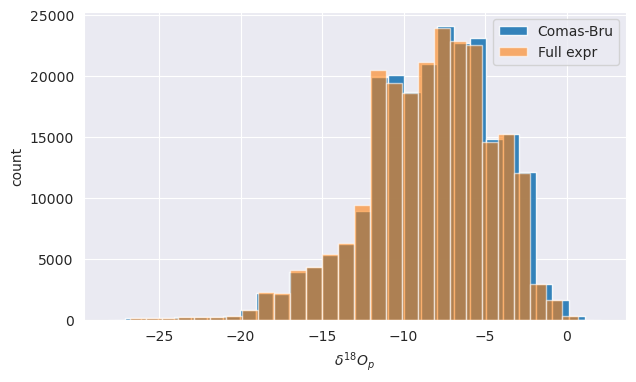

In [15]:
plt.figure(figsize=(7,4))
plt.hist(converted_data['d18Op_VSMOW_linearized'],alpha=0.9,label='Comas-Bru',bins=30)
plt.hist(converted_data['d18Op_VSMOW_exactconv'],alpha=0.6,label='Full expr',bins=30)
plt.legend()
plt.xlabel(r'$\delta^{18}O_p$')
plt.ylabel('count')
plt.grid(True)
plt.show()

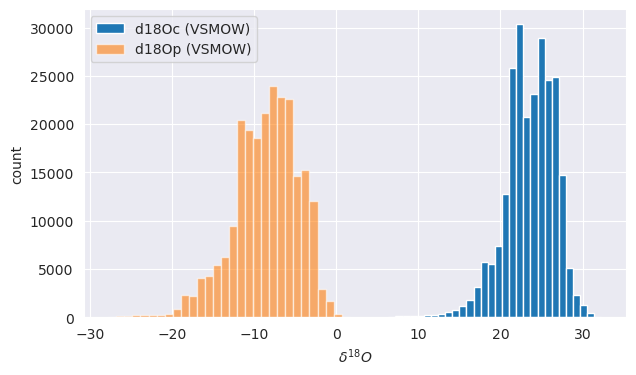

In [16]:
plt.figure(figsize=(7,4))
plt.hist(converted_data['d18Oc_VSMOW'],label='d18Oc (VSMOW)',bins=30)
# plt.hist(converted_data['d18Op_VSMOW_comasbru'],alpha=0.9,label='Comas-Bru',bins=30)
plt.hist(converted_data['d18Op_VSMOW_exactconv'],alpha=0.6,label='d18Op (VSMOW)',bins=30)
plt.legend()
plt.xlabel(r'$\delta^{18}O$')
plt.ylabel('count')
plt.grid(True)
plt.show()